# 16-Diffusion Models I: The Math

In Lessons 14 and 15, we explored Generative Adversarial Networks (GANs). While powerful, GANs are inherently unstable because they rely on Game Theory (a Minimax war between two networks). If one network gets too strong, the gradients vanish, and the model collapses.

In 2020, researchers abandoned Game Theory and turned to **Thermodynamics**.

What if we took a perfect, high-resolution image and slowly injected thermodynamic entropy (random Gaussian noise) into it until it was completely destroyed? If we could train a neural network to perfectly reverse that exact entropy process, we could start with a box of pure static noise, run the network backward, and magically synthesize a high-resolution image.

This is the mathematical foundation of **Diffusion Models** (the architecture powering Midjourney, DALL-E, and Sora).

Let's set up our PyTorch environment, load a real image of a coffee cup, and witness the thermodynamics of Diffusion.

In [1]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from skimage import data
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Thermodynamic Diffusion Environment Ready.")

✅ PyTorch Thermodynamic Diffusion Environment Ready.


# 1. The Forward Process (Destroying the Data)

The Forward Process (denoted as $q$) is a **Markov Chain**. Over a series of timesteps ($t = 1 \dots T$, where $T$ is usually 1,000), we incrementally add a tiny amount of Gaussian noise to the image.

Because it is a Markov Chain, the image at step $t$ depends *only* on the image at step $t-1$.
The mathematical definition of adding noise at a single step is:


$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t \mathbf{I})$$

### The Variance Schedule ($\beta_t$)

$\beta_t$ (Beta) is a tiny hyperparameter that controls exactly how much noise is added at step $t$. It usually starts very small (e.g., $0.0001$ at $t=1$) and grows slightly larger (e.g., $0.02$ at $t=1000$).

* We scale the previous image by $\sqrt{1 - \beta_t}$ to gently fade its pixel intensity.
* We add pure Gaussian noise scaled by $\beta_t$.

# 2. The Reparameterization Hack (Jumping to Step $T$)

There is a massive computational problem with the Markov Chain equation above. If we want to train a network on step $t=500$, do we physically have to run the noise loop 500 times in Python just to get the training data?

No. Because the sum of two Gaussian distributions is just another Gaussian distribution, we can mathematically collapse the entire loop into a single, beautiful equation.

We define a new variable, $\alpha_t = 1 - \beta_t$.
We then define $\bar{\alpha}_t$ (Alpha Bar) as the **cumulative product** of all $\alpha$ values from step $1$ to $t$.
This allows us to jump from the pristine image ($x_0$) directly to any noisy state ($x_t$) in a single calculation:

$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) \mathbf{I})$$

To sample a noisy image at step $t$, we simply grab a tensor of pure standard noise ($\epsilon$), and mix it with our original image:


$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$$

# 3. Coding the Forward Process on a Real Image

Let's write the exact PyTorch calculus to generate the Variance Schedule, load a real high-resolution test image, and mathematically destroy it using the $\bar{\alpha}_t$ shortcut.

--- 📥 Fetching Real Image Data ---


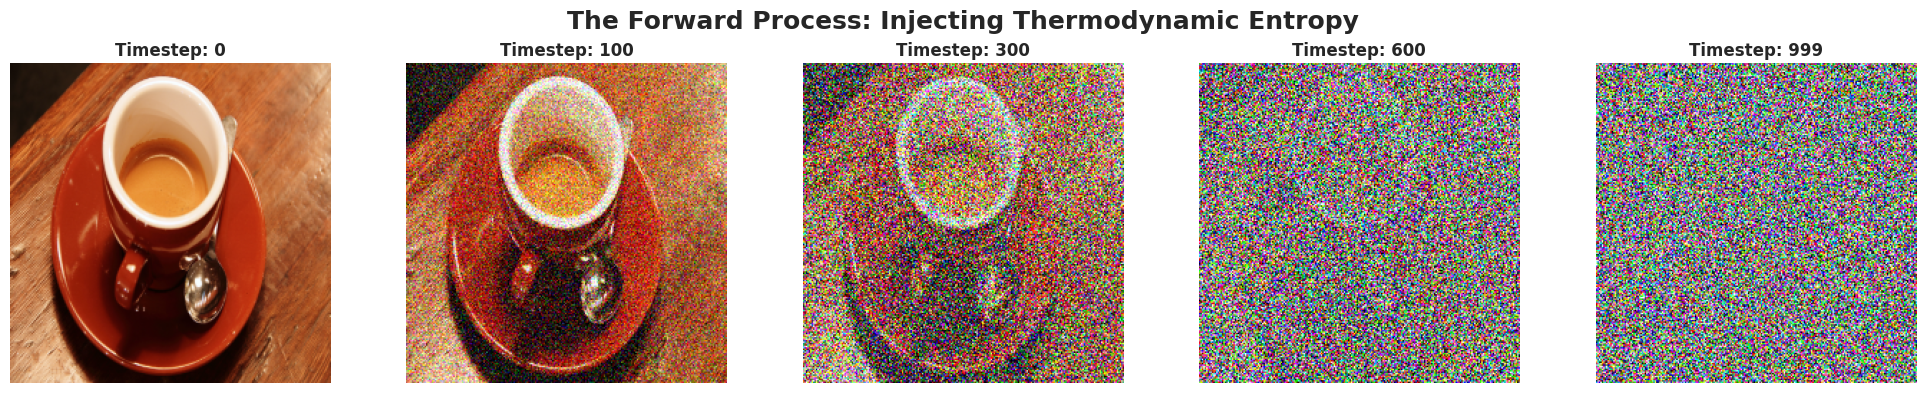

--- 💡 Engineering Insight ---
Look at the exact mathematics at play. By Step 300, the high-frequency details (reflections on the cup, saucer ridges) are gone. By Step 600, the low-frequency colors (browns/reds) are barely visible. By Step 999, the image has been mathematically pulverized into an Isotropic Gaussian Distribution. The physical structure of the coffee cup has been entirely erased by entropy.


In [2]:
# 1. Define the Variance Schedule (Linear)
T = 1000 # Total timesteps
beta_start = 0.0001
beta_end = 0.02

# beta_t: Linearly spaced noise factors
betas = torch.linspace(beta_start, beta_end, T)

# alpha_t = 1 - beta_t
alphas = 1.0 - betas

# alpha_bar_t = cumulative product of alphas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# 2. The Forward Diffusion Function (The Shortcut)
def q_sample(x_0, t, noise=None):
    """
    Jumps directly to step 't' to produce the noisy image x_t.
    Formula: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    """
    if noise is None:
        noise = torch.randn_like(x_0) # Standard N(0,1) noise
        
    # Extract the specific alpha_bar for timestep t
    # We reshape it to broadcast correctly across the image tensor [Batch, C, H, W]
    sqrt_alpha_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_cumprod_t = torch.sqrt(1.0 - alphas_cumprod[t]).view(-1, 1, 1, 1)
    
    # Execute the core thermodynamic mix
    x_t = sqrt_alpha_cumprod_t * x_0 + sqrt_one_minus_alpha_cumprod_t * noise
    return x_t

# 3. Fetch and Preprocess a Real Computer Vision Test Image
print("--- 📥 Fetching Real Image Data ---")
numpy_coffee = data.coffee()
# Resize for consistency
resized_coffee = resize(numpy_coffee, (224, 224), anti_aliasing=True)

# Deep Learning Normalization for Diffusion: Scale to [-1.0, 1.0]
normalized_coffee = (resized_coffee * 2.0) - 1.0
x_0 = torch.tensor(normalized_coffee, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

# 4. Visualizing the Destruction of Reality
timesteps = [0, 100, 300, 600, 999]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("The Forward Process: Injecting Thermodynamic Entropy", fontsize=18, fontweight='bold')

for i, t in enumerate(timesteps):
    if t == 0:
        x_t = x_0 # Pristine image
    else:
        # We must pass the timestep as a tensor!
        t_tensor = torch.tensor([t])
        x_t = q_sample(x_0, t_tensor)
        
    # Convert tensor back to HWC format
    img_display = x_t.squeeze(0).permute(1, 2, 0).numpy()
    # Un-normalize [-1.0, 1.0] back to [0.0, 1.0] for matplotlib
    img_display = (img_display * 0.5) + 0.5
    img_display = np.clip(img_display, 0, 1)
    
    axes[i].imshow(img_display)
    axes[i].set_title(f"Timestep: {t}", fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("--- 💡 Engineering Insight ---")
print("Look at the exact mathematics at play. By Step 300, the high-frequency details (reflections on the cup, saucer ridges) are gone. By Step 600, the low-frequency colors (browns/reds) are barely visible. By Step 999, the image has been mathematically pulverized into an Isotropic Gaussian Distribution. The physical structure of the coffee cup has been entirely erased by entropy.")

# 4. The Reverse Process (The Neural Network)

We have successfully destroyed the data. Now, we must train a Neural Network (usually a deep U-Net, denoted as $\epsilon_\theta$) to reverse the process.

**What exactly does the network predict?**
It does *not* look at the static noise at step 999 and try to predict the perfect, pristine coffee cup in one jump. That is mathematically impossible.

Instead, the network looks at the image at step $t$ (e.g., $t=300$), and predicts **the exact noise matrix ($\epsilon$) that was added to the image at that specific step**.
Once the network predicts the noise, we use strict algebra to subtract that predicted noise out of the image, taking a microscopic step backward from $t=300$ to $t=299$.

# 5. The Loss Function (Why Diffusion is Stable)

Because the network is just predicting a noise matrix, what is the Loss Function?

It is the simplest, most stable loss function in all of Machine Learning: **Mean Squared Error (MSE)**.

$$L = \mathbb{E}_{t, x_0, \epsilon} \left[ ||\epsilon - \epsilon_\theta(\underbrace{\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon}_{x_t}, t)||^2 \right]$$

**The Enterprise Training Loop:**

1. Pick a random real image ($x_0$) from your dataset.
2. Pick a random timestep ($t$) between 1 and 1000.
3. Generate a pure random noise matrix ($\epsilon$).
4. Use our `q_sample` formula to corrupt $x_0$ into $x_t$ using that exact $\epsilon$.
5. Pass $x_t$ and the timestep $t$ into the Neural Network ($\epsilon_\theta$).
6. Calculate the MSE between the *true* noise ($\epsilon$) and the *predicted* noise ($\epsilon_\theta$).
7. Backpropagate.

There is no Discriminator. There is no Minimax game. The network simply learns to act as a mathematical vacuum cleaner, perfectly sucking noise out of a matrix one microscopic layer at a time.


## Real-World Use Case or Analogy:

Think of Diffusion Models like **A Master Sculptor and a Block of Marble**:

* **The Forward Process (Entropy)**: You start with a perfectly carved marble statue of a coffee cup. Every day for 1,000 days, you hit the statue with a tiny hammer, knocking off a few grains of marble. On day 1,000, you are left with a featureless, random pile of dust and gravel (Pure Noise).
* **GANs (The Magician)**: A GAN tries to snap its fingers and instantly turn the pile of dust back into a perfect cup in one single millisecond. It's incredibly difficult, unstable, and usually results in weird, unnatural mutations.
* **Diffusion (The Sculptor)**: The Diffusion network doesn't try to build the cup instantly. It looks at the pile of dust on day 1,000, and simply asks: *"Which 5 grains of dust were added by the hammer on day 999?"* It sweeps away those 5 grains. Then it looks at the pile on day 999 and sweeps away the dust from day 998. It repeats this microscopic, highly controlled cleanup process 1,000 times, mathematically guaranteeing that the final result is a flawless, perfect statue.